# Bytewise Fellowship Week 7

# Dataset : Wholesale Customers Dataset
## K-Means Clustering for Customer Segmentation

- **Task: 1**
    - Use K-Means clustering to segment customers in the Wholesale Customers dataset based on their annual spending in different categories. Visualize the clusters.

    - Evaluating the Optimal Number of Clusters

- **Task: 2**
    - Determine the optimal number of clusters for the Wholesale Customers dataset using the Elbow Method and Silhouette Score. Visualize the results and justify your choice.

    - Cluster Analysis and Interpretation

- **Task: 3**
    - Interpret the clusters formed in the Wholesale Customers dataset. Identify the characteristics and differences among the clusters based on spending behavior.

    - Hierarchical Clustering: Dendrogram and Cluster Formation

- **Task: 4**
    - Apply hierarchical clustering to the Wholesale Customers dataset and visualize the dendrogram. Compare the cluster assignments with those obtained from K-Means.

    - Comparison of Clustering Results

- **Task: 5**
    - Compare the effectiveness of K-Means and hierarchical clustering on the Wholesale Customers dataset. Discuss the results in terms of cluster cohesion and separation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans
plt.figure(figsize=(10, 7))
import warnings
warnings.filterwarnings('ignore')

<Figure size 1000x700 with 0 Axes>

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Datasets /BWF_Week7_Dataset/Wholesale customers data.csv')  # Replace 'your_dataset.csv' with the actual file path

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# Task 1

In [4]:
# Select relevant features for clustering
X = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # You can start with 3 clusters
clusters = kmeans.fit_predict(X)

# Add the cluster labels to the dataset
df['Cluster'] = clusters


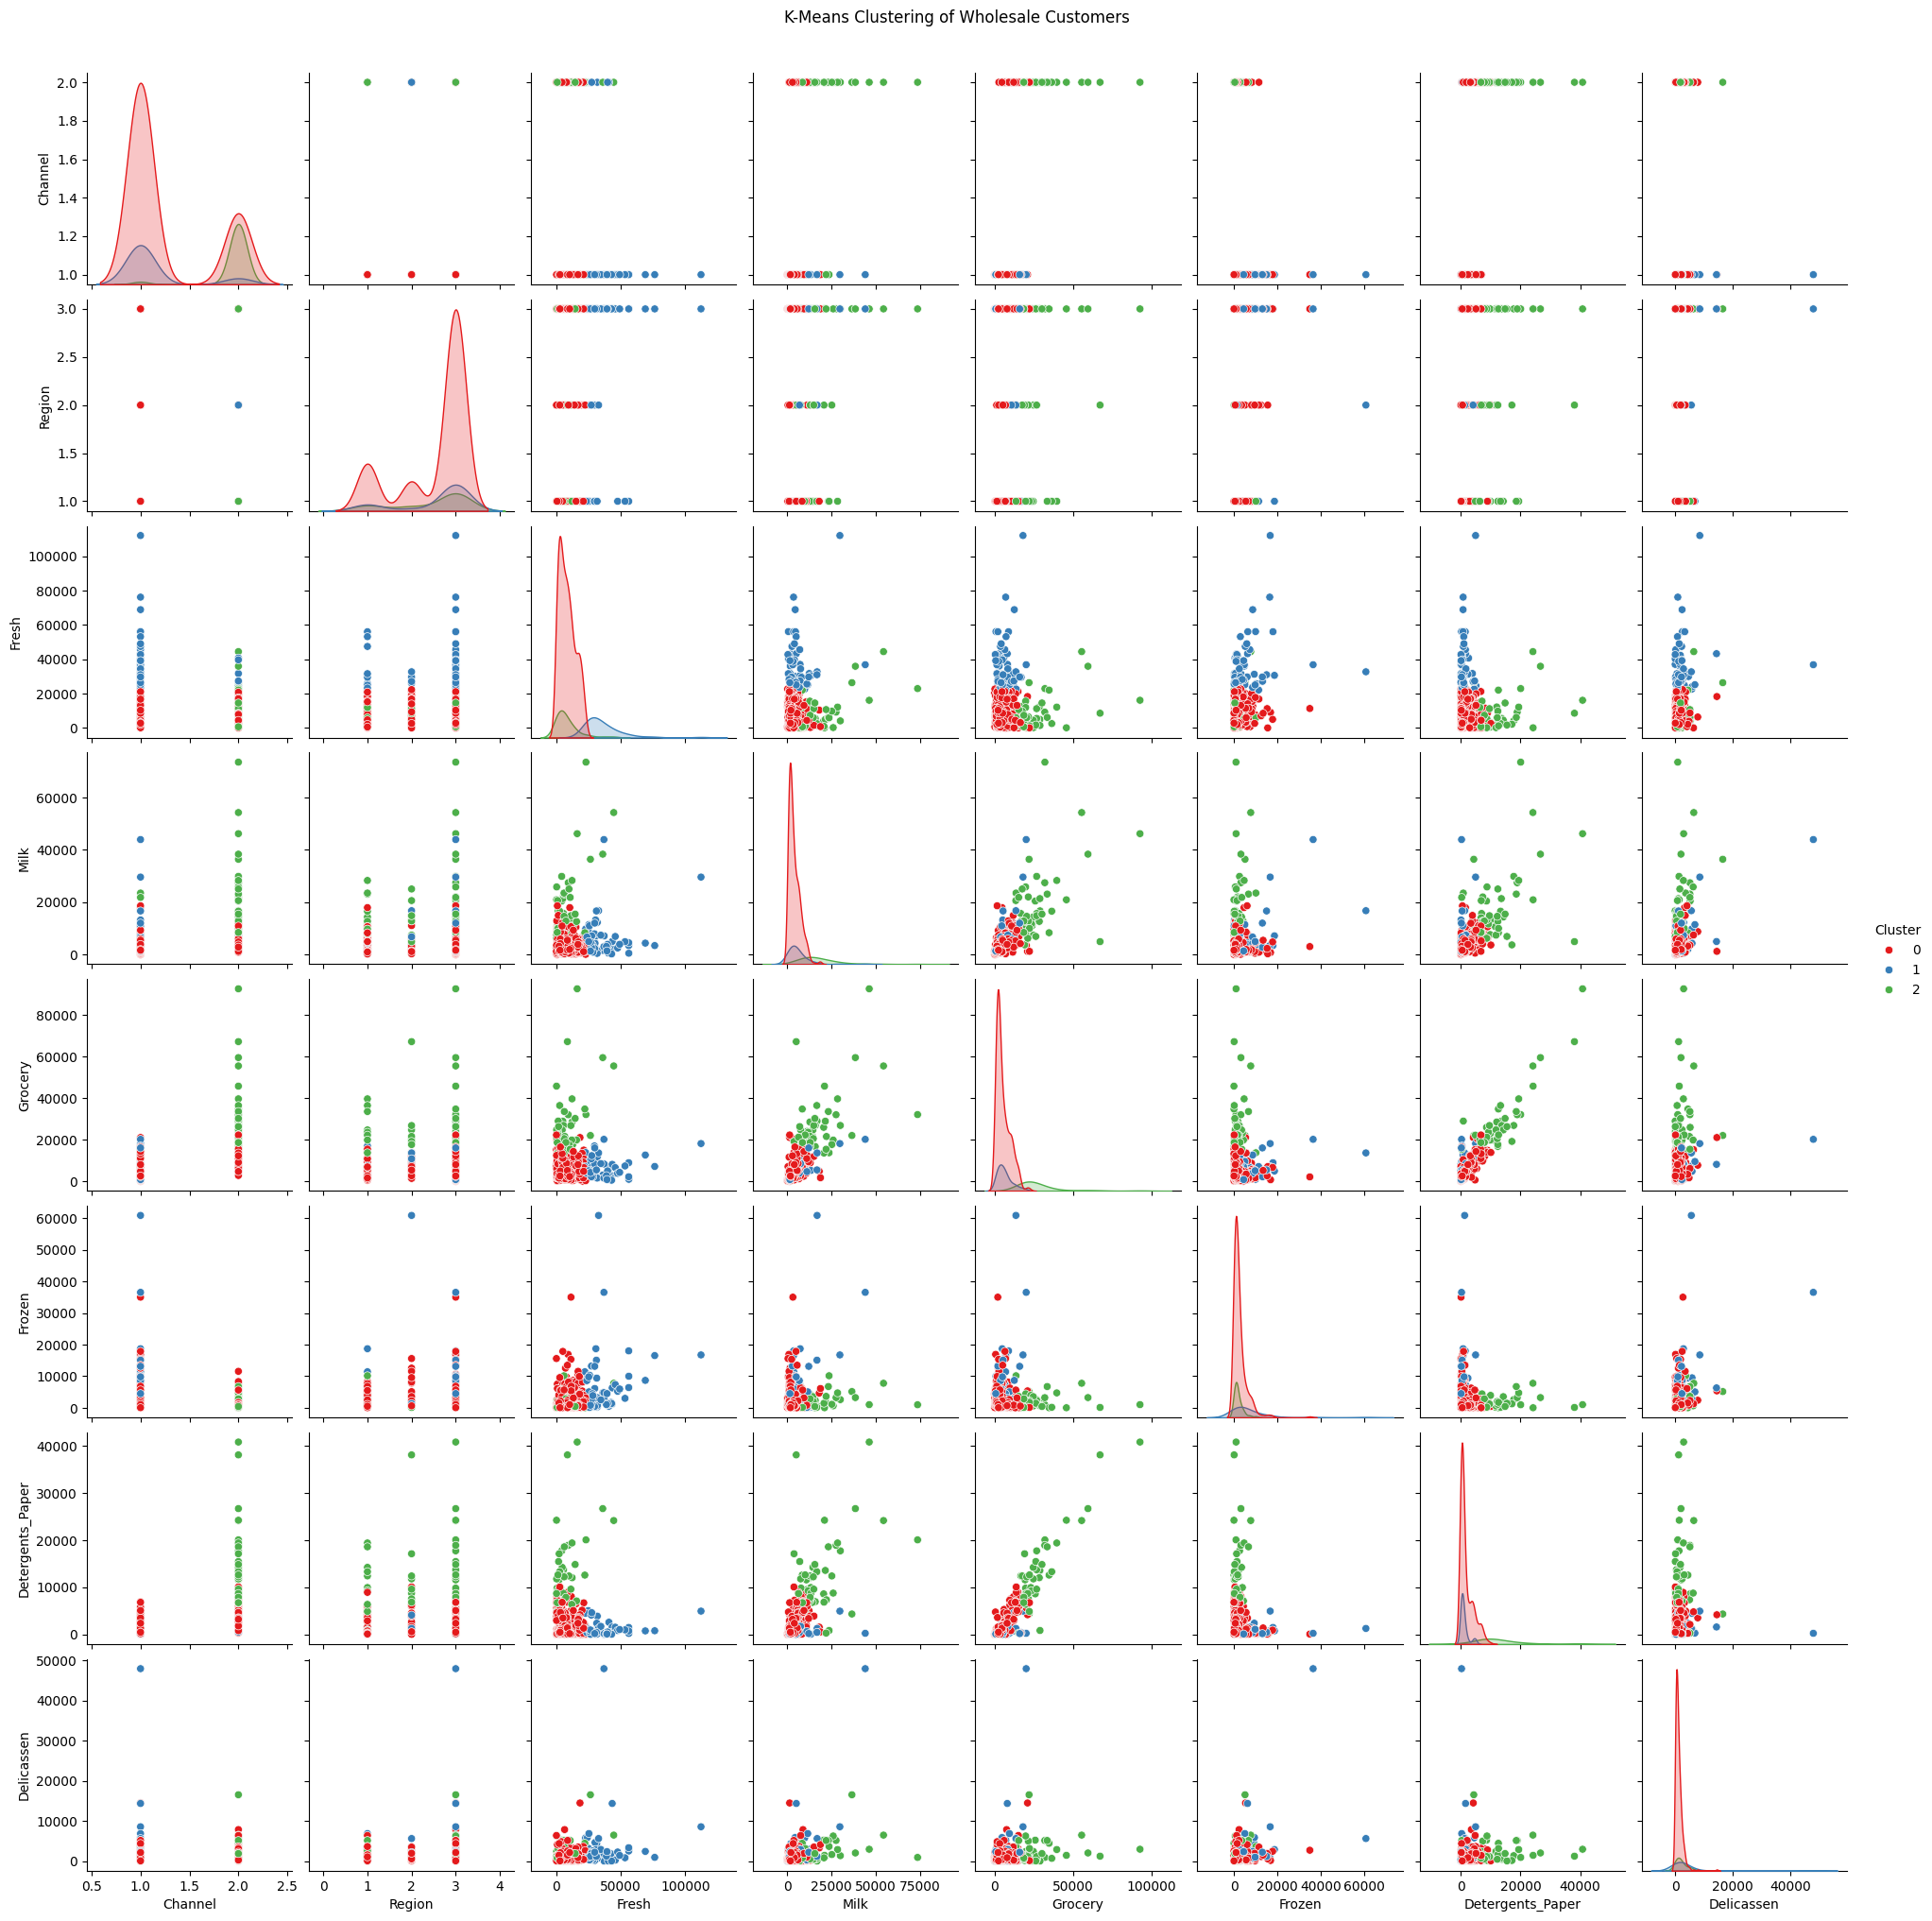

In [6]:
# Visualize the clusters using a pairplot
sns.pairplot(df, hue='Cluster', palette='Set1')
plt.suptitle("K-Means Clustering of Wholesale Customers", y=1.02)  # Adding a title
plt.show()

# Task 2

### Evaluating the Optimal Number of Clusters

In [7]:
# the optimal number of clusters using the Elbow Method
sse = []  # List to store the sum of squared errors for each k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # Append the SSE (inertia) for each k

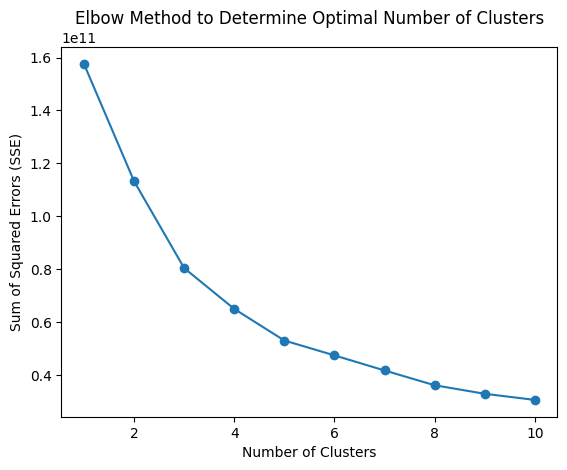

In [8]:
# Plot the Elbow Method result
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

In [9]:
from sklearn.metrics import silhouette_score  # For calculating silhouette score

# Calculate Silhouette Scores for k = 2 to k = 10
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))


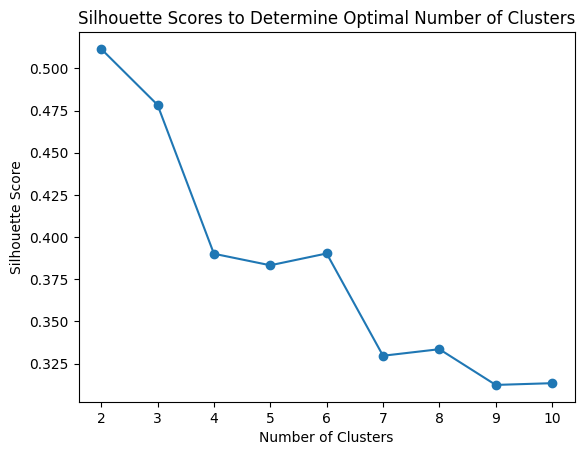

In [10]:
# Plot the Silhouette Scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

- **Elbow Method:** The elbow method helps determine the optimal number of clusters by identifying the point where adding more clusters doesn't significantly reduce the SSE.

- **Silhouette Score:** This score helps in identifying how well-separated the clusters are, with higher values indicating better-defined clusters.